In [19]:
from matplotlib.lines import Line2D
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import re
import seaborn as sns
import yaml

from country_config import *
from run_config import *
from utils import *

In [20]:
# for all folders starting with validation*

total_monthly_population_dfs = []
total_monthly_population_df_names = []

folders = ["validation_1_copy_0.25_population_scale_one_pattern_15_replicates", "validation_10_copy_0.25_population_scale_one_pattern_15_replicates", "validation_1_copy_new_treatment_seeking_0.25_population_scale_one_pattern_15_replicates", "validation_1_copy_new_beta_raster_0.25_population_scale_one_pattern_15_replicates"]

for folder in folders:
    # print(f"Processing folder: {folder}")
    # get the path to the folder
    folder_path = Path(folder)

    analysis_path = folder_path / "analysis"
    if analysis_path.exists():
        # if there is a file called "total_population_by_month.csv" in the analysis sub directory
        total_population_by_month_path = analysis_path / "total_population_by_month.csv"
        if total_population_by_month_path.exists():
            print(f"Found total_population_by_month.csv in {analysis_path}")
            # read the CSV file into a pandas DataFrame
            df = pd.read_csv(total_population_by_month_path)
            total_monthly_population_dfs.append(df)

            # Match numbers + dot + numbers + M (e.g. 20.5M, 20.38M)
            match = re.search(r'\d+\.\d+M', folder)
            if match:
                folder_label = match.group(0)
            else:
                folder_label = folder  # Fallback if match fails
            
            total_monthly_population_df_names.append(folder_label)


Found total_population_by_month.csv in validation_1_copy_0.25_population_scale_one_pattern_15_replicates/analysis
Found total_population_by_month.csv in validation_10_copy_0.25_population_scale_one_pattern_15_replicates/analysis
Found total_population_by_month.csv in validation_1_copy_new_treatment_seeking_0.25_population_scale_one_pattern_15_replicates/analysis
Found total_population_by_month.csv in validation_1_copy_new_beta_raster_0.25_population_scale_one_pattern_15_replicates/analysis


In [21]:
print(f"Total monthly population DataFrames loaded: {len(total_monthly_population_dfs)}")
print(f"Total monthly population DataFrame names: {total_monthly_population_df_names}")

Total monthly population DataFrames loaded: 4
Total monthly population DataFrame names: ['validation_1_copy_0.25_population_scale_one_pattern_15_replicates', 'validation_10_copy_0.25_population_scale_one_pattern_15_replicates', 'validation_1_copy_new_treatment_seeking_0.25_population_scale_one_pattern_15_replicates', 'validation_1_copy_new_beta_raster_0.25_population_scale_one_pattern_15_replicates']


In [22]:
test_df = total_monthly_population_dfs[0]
test_df

,monthly_data_id,population_5,population_6,population_14,mean_population
0,1,20371912.0,20371812.0,20371892.0,20371877
1,2,20403528.0,20402392.0,20404000.0,20403015
2,3,20428512.0,20428444.0,20429484.0,20428164
3,4,20455448.0,20456108.0,20457068.0,20455122
4,5,20482156.0,20482544.0,20483276.0,20481599
5,6,20510272.0,20511592.0,20512468.0,20509779
6,7,20538488.0,20540316.0,20540820.0,20538125
7,8,20569780.0,20569672.0,20571036.0,20568160
8,9,20600312.0,20599572.0,20603268.0,20598903
9,10,20630488.0,20629888.0,20633068.0,20629336


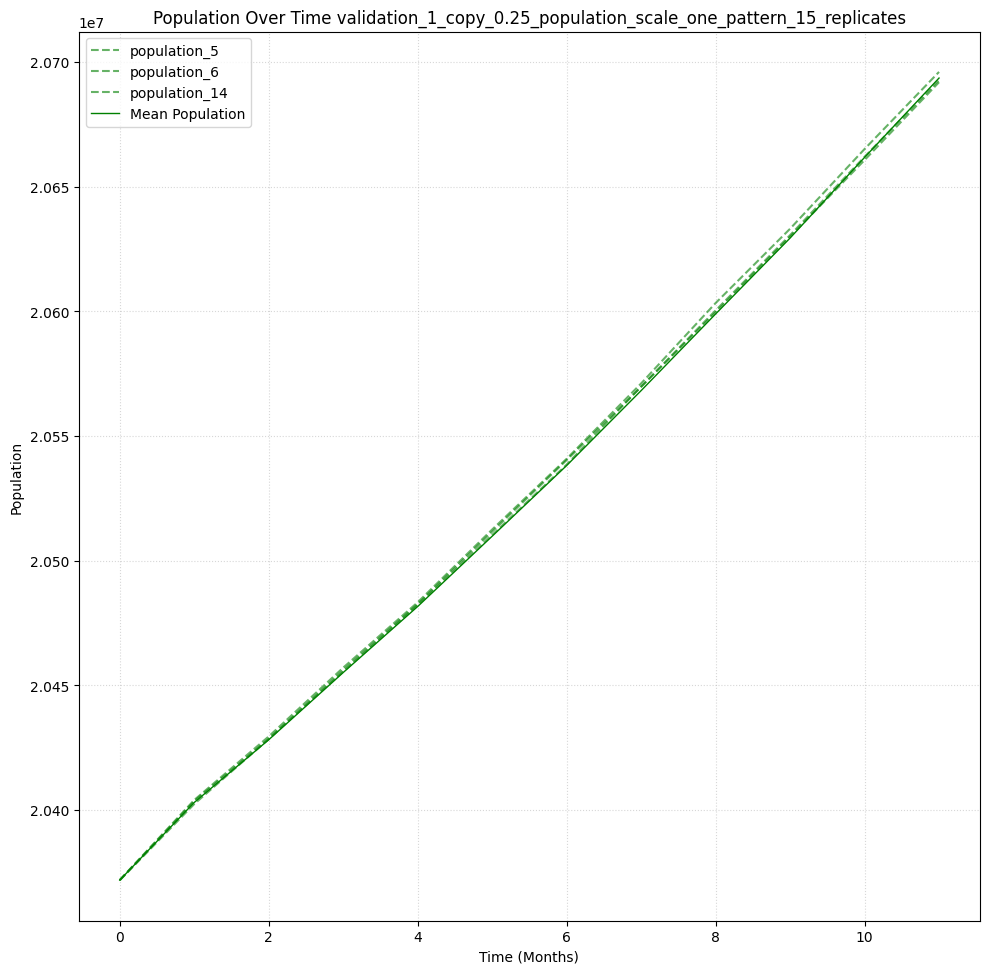

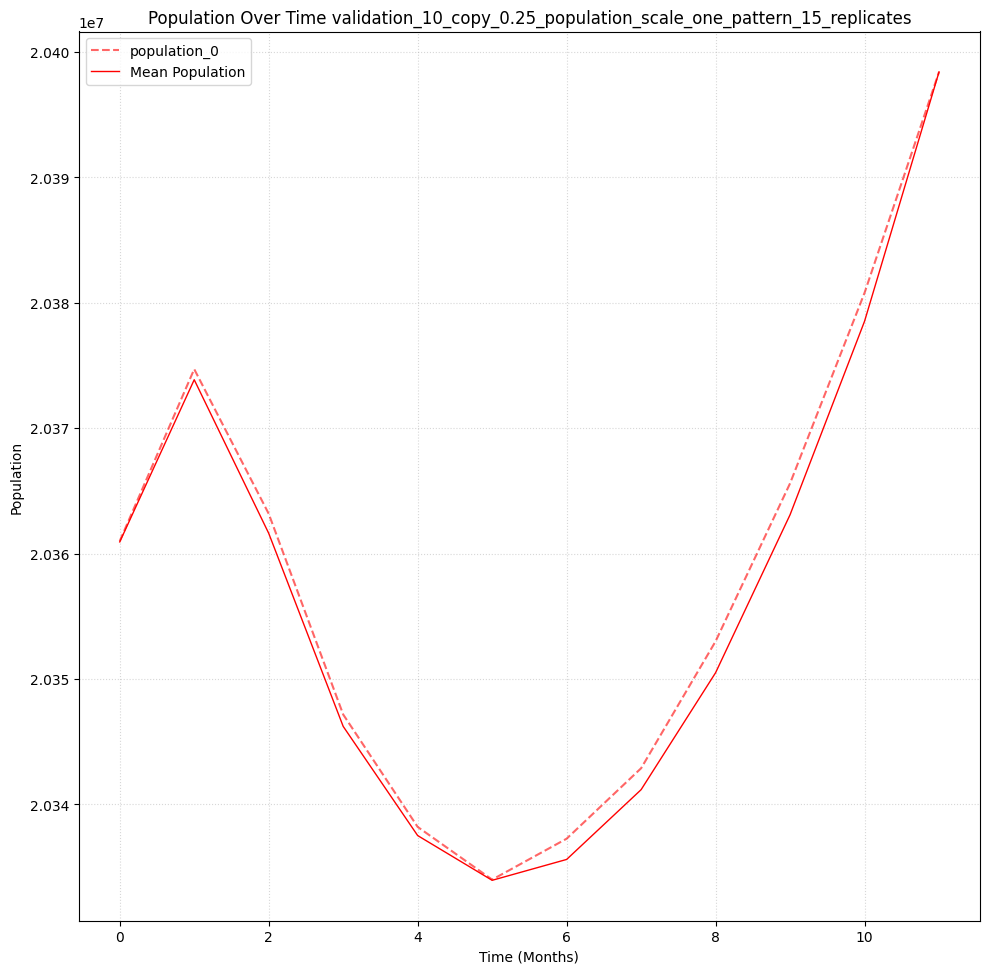

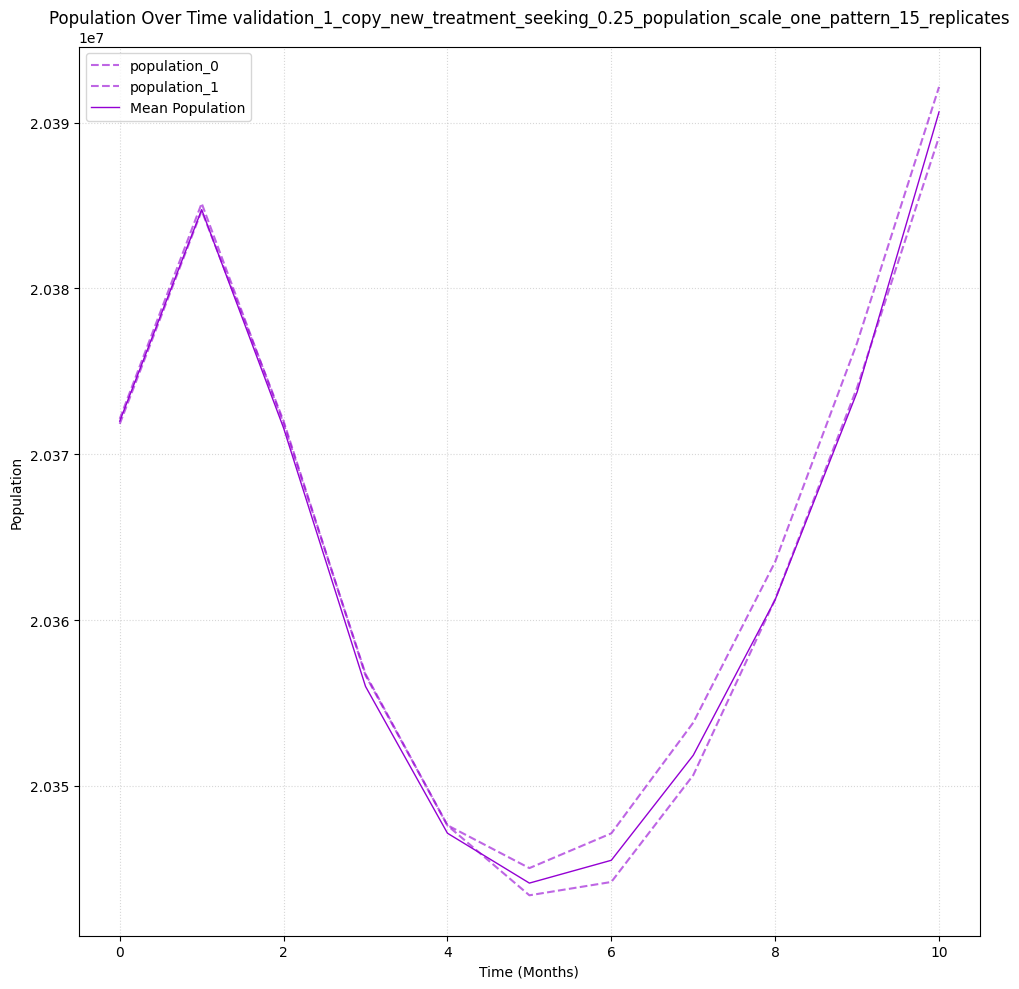

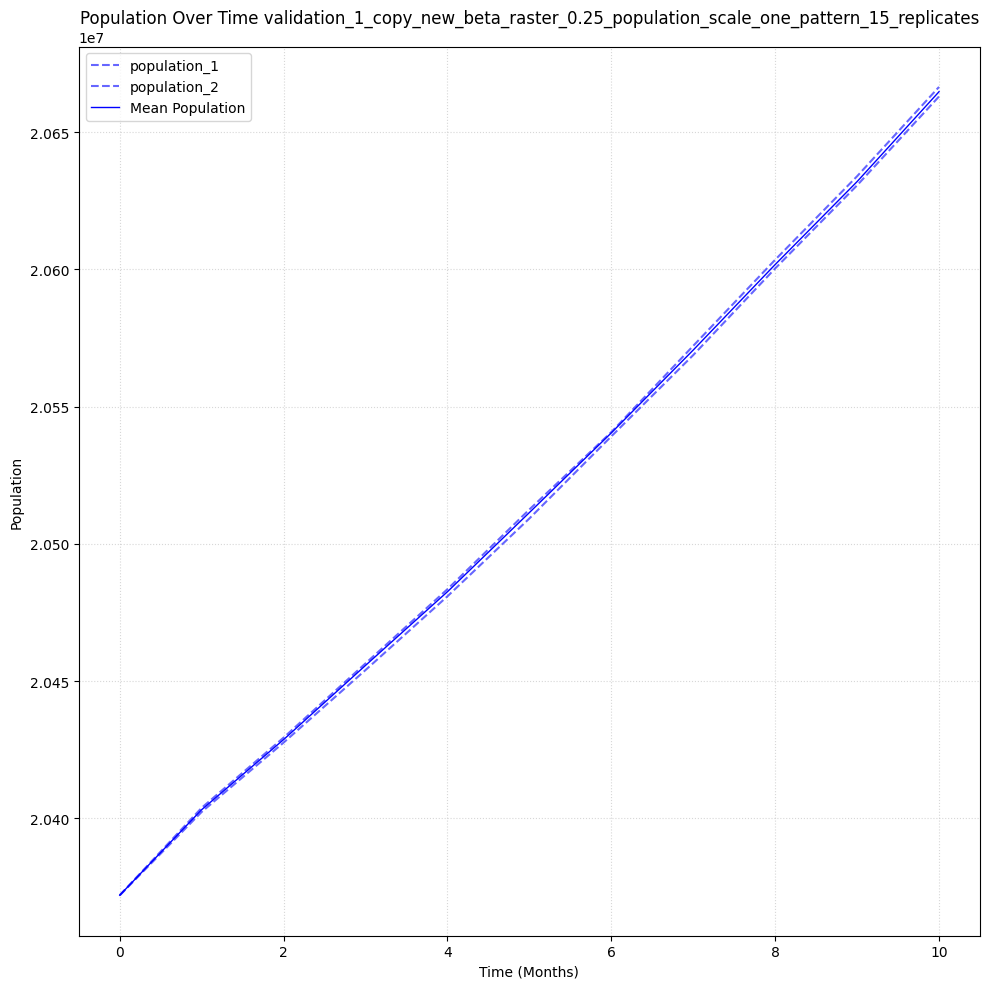

In [23]:
# Define colors for each DataFrame
colors = ['green', 'red', 'darkviolet', 'blue']

for i, df in enumerate(total_monthly_population_dfs):
    # Select color (cycles if there are more DataFrames than colors listed)
    color = colors[i % len(colors)]
    
    plt.figure(figsize=(10, 10))
    
    # 1. Plot numbered population columns as dashed lines
    pop_cols = [col for col in df.columns if col.startswith('population_')]
    for col in pop_cols:
        plt.plot(
            df.tail(12).index, 
            df.tail(12)[col], 
            linestyle='--', 
            color=color, 
            alpha=0.6, 
            label=col
        )
    
    # 2. Plot mean population as a thick solid line
    if 'mean_population' in df.columns:
        plt.plot(
            df.tail(12).index, 
            df.tail(12)['mean_population'], 
            linestyle='-', 
            color=color, 
            linewidth=1, 
            label='Mean Population'
        )
    
    plt.title(f'Population Over Time {total_monthly_population_df_names[i]}')
    plt.xlabel('Time (Months)')
    plt.ylabel('Population')
    plt.legend(loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()

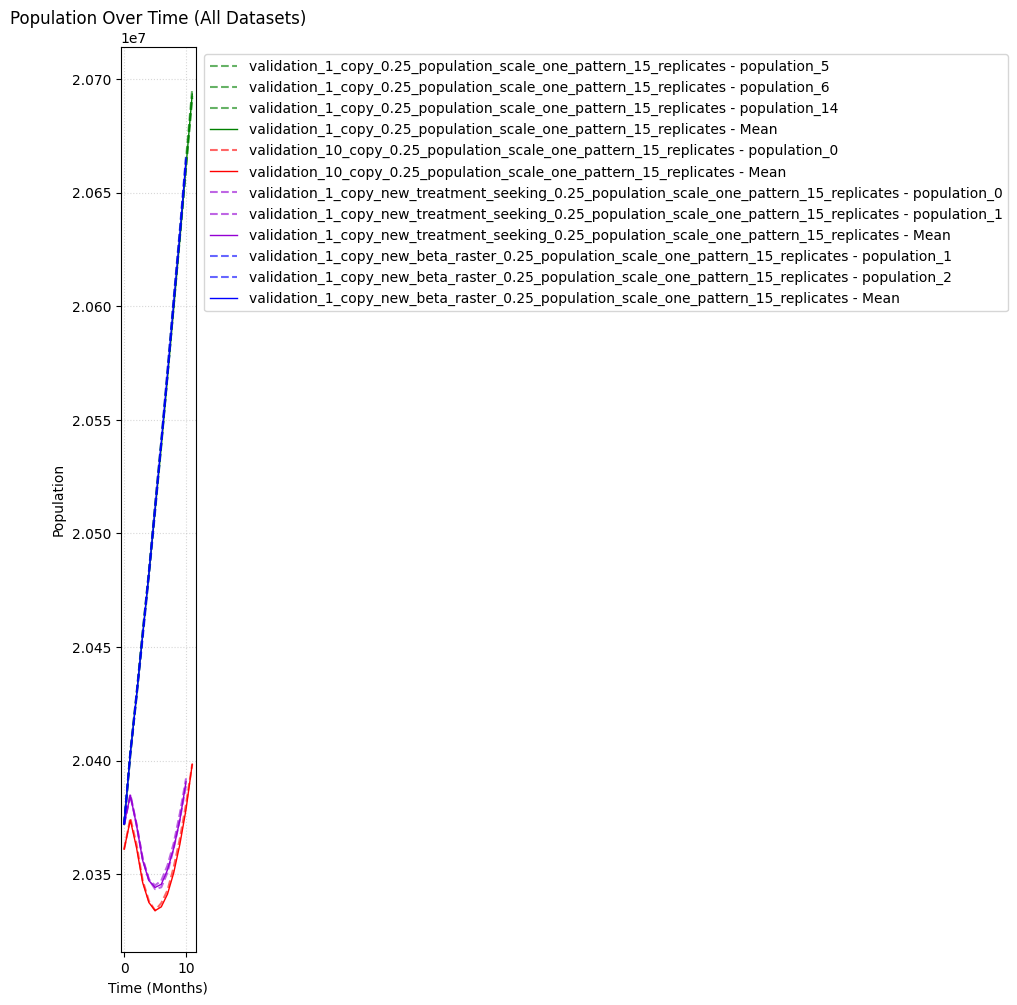

In [24]:
# Initialize a single figure before looping
plt.figure(figsize=(10, 10))

for i, df in enumerate(total_monthly_population_dfs):
    color = colors[i % len(colors)]
    
    # 1. Plot numbered population columns as dashed lines
    pop_cols = [col for col in df.columns if col.startswith('population_')]
    for col in pop_cols:
        plt.plot(
            df.index, 
            df[col], 
            linestyle='--', 
            color=color, 
            alpha=0.6, 
            label=f'{total_monthly_population_df_names[i]} - {col}'
        )
    
    # 2. Plot mean population as a solid line
    if 'mean_population' in df.columns:
        plt.plot(
            df.index, 
            df['mean_population'], 
            linestyle='-', 
            color=color, 
            linewidth=1, 
            label=f'{total_monthly_population_df_names[i]} - Mean'
        )

# Format and display the combined chart after all DataFrames are plotted
plt.title('Population Over Time (All Datasets)')
plt.xlabel('Time (Months)')
plt.ylabel('Population')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))  # Legend moved outside to prevent overlapping
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

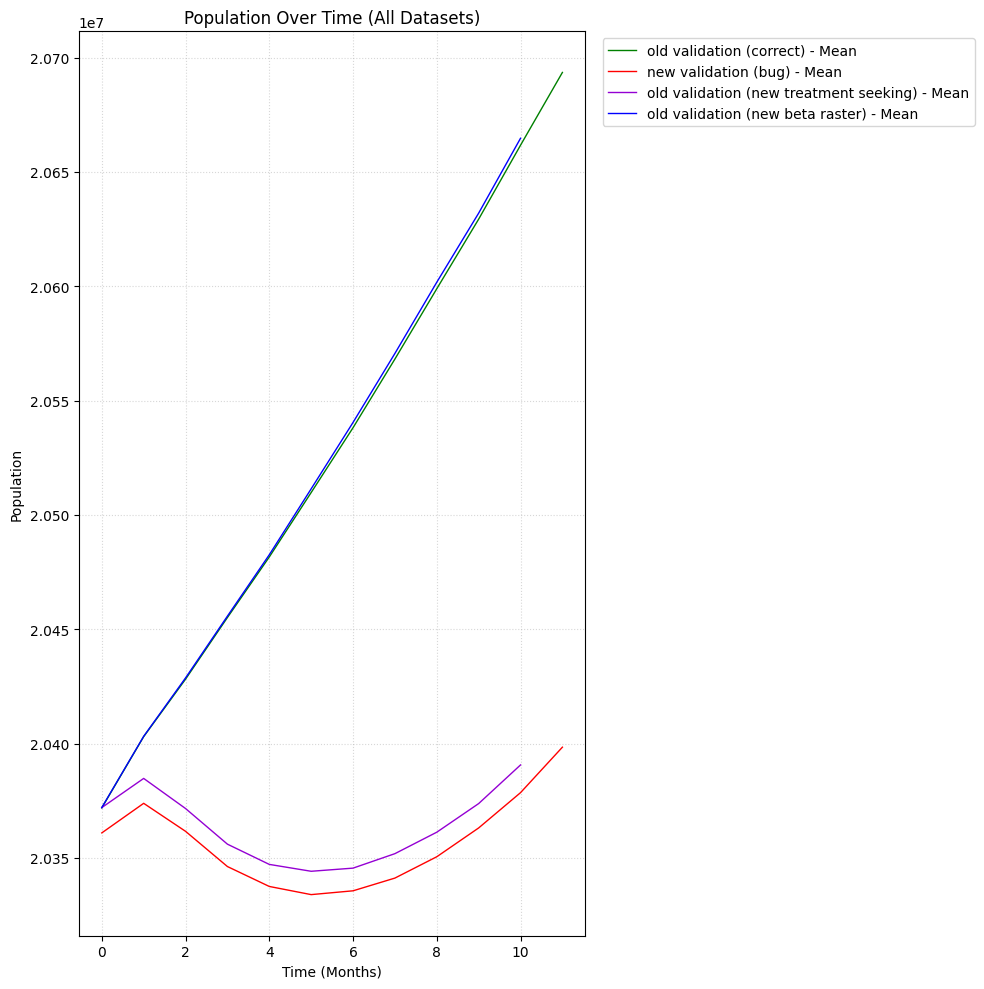

In [26]:
# Initialize a single figure before looping
plt.figure(figsize=(10, 10))

custom_labels = ["old validation (correct)", "new validation (bug)", "old validation (new treatment seeking)", "old validation (new beta raster)"]

for i, df in enumerate(total_monthly_population_dfs):
    color = colors[i % len(colors)]
    
    # # 1. Plot numbered population columns as dashed lines
    # pop_cols = [col for col in df.columns if col.startswith('population_')]
    # for col in pop_cols:
    #     plt.plot(
    #         df.head(12).index, 
    #         df.head(12)[col], 
    #         linestyle='--', 
    #         color=color, 
    #         alpha=0.6, 
    #         label=f'{total_monthly_population_df_names[i]} - {col}'
    #     )
    
    # 2. Plot mean population as a solid line
    if 'mean_population' in df.columns:
        plt.plot(
            df.head(12).index, 
            df.head(12)['mean_population'], 
            linestyle='-', 
            color=color, 
            linewidth=1, 
            label=f'{custom_labels[i]} - Mean'
        )

# Format and display the combined chart after all DataFrames are plotted
plt.title('Population Over Time (All Datasets)')
plt.xlabel('Time (Months)')
plt.ylabel('Population')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))  # Legend moved outside to prevent overlapping
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(Path(f"analysis/pop_growth_rate_bug.png"), dpi=200)
plt.show()